In [ ]:
# 04 그래프 그리기
# 04-1 데이터 시각화가 필요한 이유

In [9]:
import seaborn as sns

anscombe = sns.load_dataset("anscombe")
print(anscombe)
print(type(anscombe))

   dataset     x      y
0        I  10.0   8.04
1        I   8.0   6.95
2        I  13.0   7.58
3        I   9.0   8.81
4        I  11.0   8.33
5        I  14.0   9.96
6        I   6.0   7.24
7        I   4.0   4.26
8        I  12.0  10.84
9        I   7.0   4.82
10       I   5.0   5.68
11      II  10.0   9.14
12      II   8.0   8.14
13      II  13.0   8.74
14      II   9.0   8.77
15      II  11.0   9.26
16      II  14.0   8.10
17      II   6.0   6.13
18      II   4.0   3.10
19      II  12.0   9.13
20      II   7.0   7.26
21      II   5.0   4.74
22     III  10.0   7.46
23     III   8.0   6.77
24     III  13.0  12.74
25     III   9.0   7.11
26     III  11.0   7.81
27     III  14.0   8.84
28     III   6.0   6.08
29     III   4.0   5.39
30     III  12.0   8.15
31     III   7.0   6.42
32     III   5.0   5.73
33      IV   8.0   6.58
34      IV   8.0   5.76
35      IV   8.0   7.71
36      IV   8.0   8.84
37      IV   8.0   8.47
38      IV   8.0   7.04
39      IV   8.0   5.25
40      IV  19.0

In [10]:
%matplotlib notebook
import matplotlib.pyplot as plt

%matplotlib inline

In [11]:
dataset_1 = anscombe[anscombe['dataset'] == 'I']

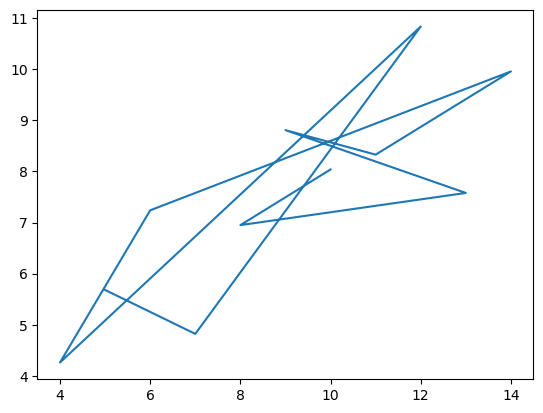

In [12]:
plt.plot(dataset_1['x'], dataset_1['y'])

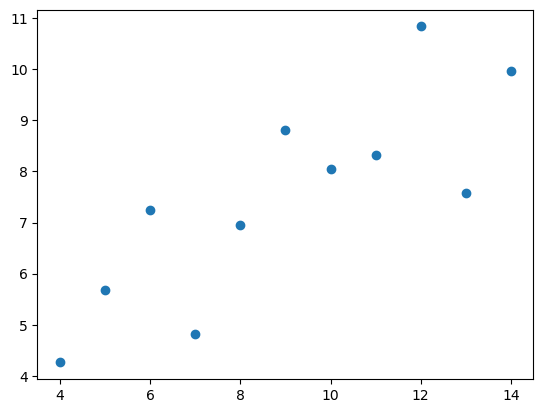

In [13]:
plt.plot(dataset_1['x'], dataset_1['y'], 'o')

In [14]:
# 한 번에 4개의 그래프 그리기

In [15]:
dataset_2 = anscombe[anscombe['dataset'] == 'II']
dataset_3 = anscombe[anscombe['dataset'] == 'III']
dataset_4 = anscombe[anscombe['dataset'] == 'IV']

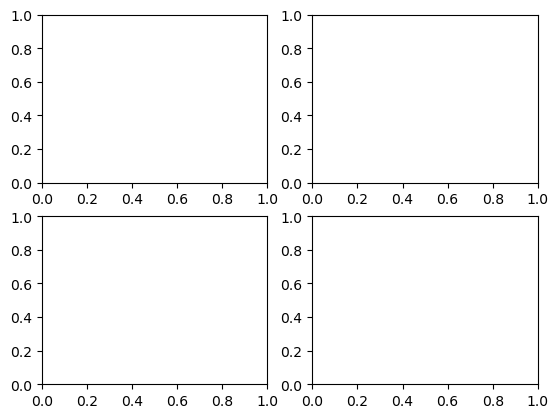

In [16]:
fig = plt.figure()
axes1 = fig.add_subplot(2, 2, 1)
axes2 = fig.add_subplot(2, 2, 2)
axes3 = fig.add_subplot(2, 2, 3)
axes4 = fig.add_subplot(2, 2, 4)

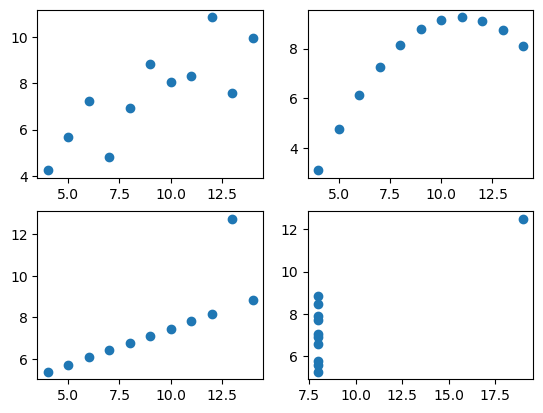

In [17]:
axes1.plot(dataset_1['x'], dataset_1['y'], 'o')
axes2.plot(dataset_2['x'], dataset_2['y'], 'o')
axes3.plot(dataset_3['x'], dataset_3['y'], 'o')
axes4.plot(dataset_4['x'], dataset_4['y'], 'o')

fig

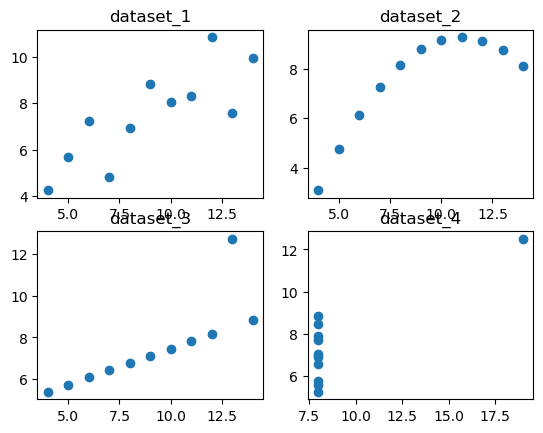

In [18]:
axes1.set_title("dataset_1")
axes2.set_title("dataset_2")
axes3.set_title("dataset_3")
axes4.set_title("dataset_4")

fig

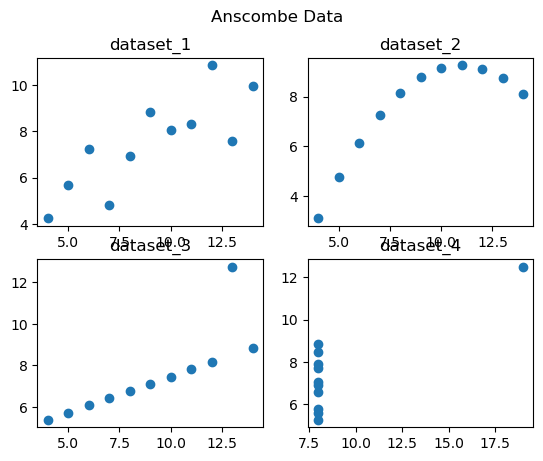

In [19]:
fig.suptitle("Anscombe Data")
fig

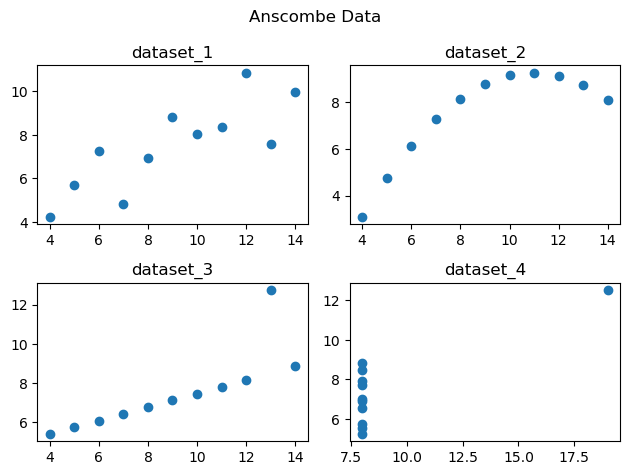

In [20]:
fig.tight_layout()

fig

In [21]:
# 04-2 matplotlib 라이브러리 자유자재로 사용하기

In [22]:
tips = sns.load_dataset("tips")
print(tips.head())
print(type(tips))

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
<class 'pandas.core.frame.DataFrame'>


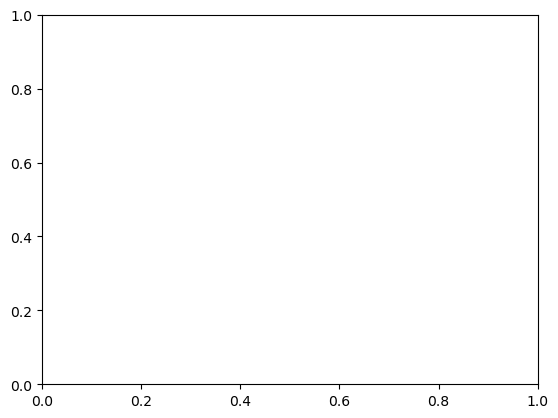

In [23]:
fig = plt.figure()
axes1 = fig.add_subplot(1, 1, 1)

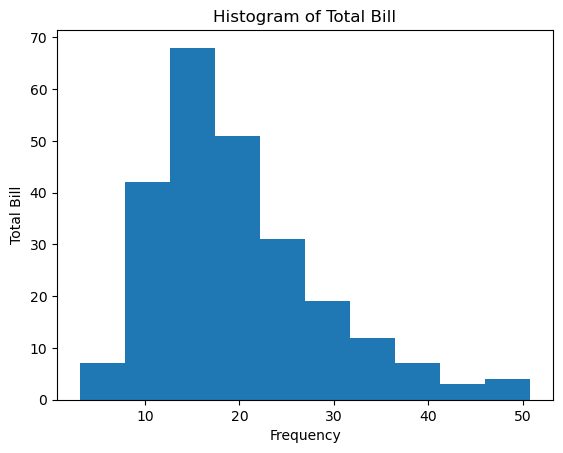

In [24]:
axes1.hist(tips['total_bill'], bins=10)
axes1.set_title('Histogram of Total Bill')
axes1.set_xlabel('Frequency')
axes1.set_ylabel('Total Bill')

fig

Text(0, 0.5, 'Tip')

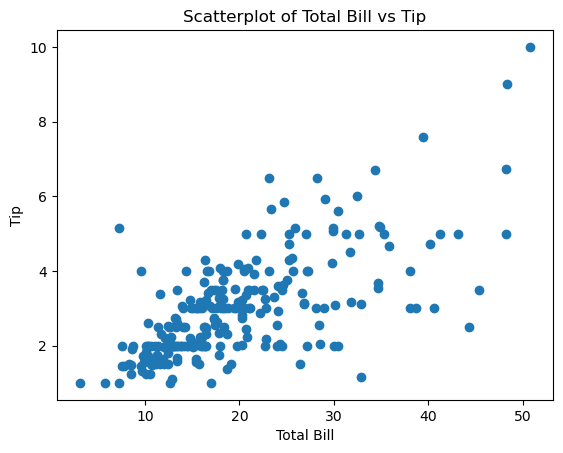

In [25]:
scatter_plot = plt.figure()
axes1 = scatter_plot.add_subplot(1, 1, 1)
axes1.scatter(tips['total_bill'], tips['tip'])
axes1.set_title('Scatterplot of Total Bill vs Tip')
axes1.set_xlabel('Total Bill')
axes1.set_ylabel('Tip')

Text(0.5, 1.0, 'Boxplot of Tips by Sex')

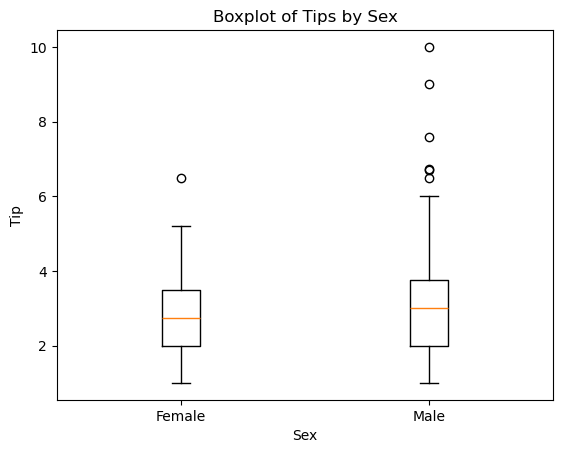

In [26]:
boxplot = plt.figure()
axes1 = boxplot.add_subplot(1, 1, 1)

axes1.boxplot([tips[tips['sex'] == 'Female']['tip'],
               tips[tips['sex'] == 'Male']['tip']],
               tick_labels=['Female', 'Male'])
axes1.set_xlabel('Sex')
axes1.set_ylabel('Tip')
axes1.set_title('Boxplot of Tips by Sex')
# labels -> tick_labels 변경

In [27]:
# 다변량 데이터로 다변량 그래프 그리기 - 산점도 그래프
def recode_sex(sex):
    if sex == 'Female':
        return 0
    else:
        return 1

In [28]:
tips['sex_color'] = tips['sex'].apply(recode_sex)

Text(0, 0.5, 'Tip')

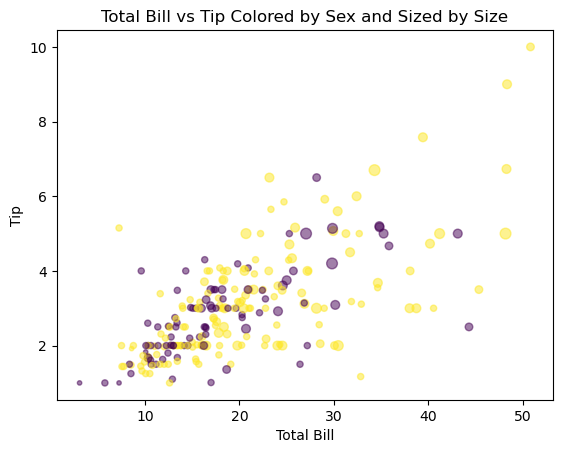

In [29]:
scatter_plot = plt.figure()
axes1 = scatter_plot.add_subplot(1, 1, 1)
axes1.scatter(
    x=tips['total_bill'],
    y=tips['tip'],
    s=tips['size']*10,
    c=tips['sex_color'],
    alpha=0.5)
axes1.set_title('Total Bill vs Tip Colored by Sex and Sized by Size')
axes1.set_xlabel('Total Bill')
axes1.set_ylabel('Tip')

In [30]:
# 04-3 seaborn 라이브러리 자유자재로 사용하기

In [31]:
# 단변량 그래프 그리기 - 히스토그램
import seaborn as sns
tips = sns.load_dataset("tips")

Text(0.5, 1.0, 'Total Bill Histogram with Density Plot')

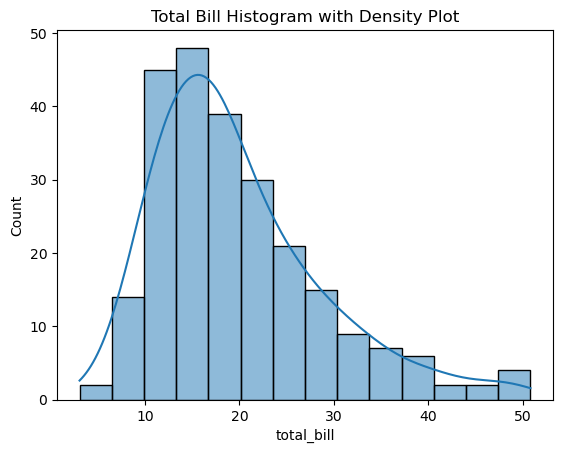

In [32]:
ax = sns.histplot(tips['total_bill'], kde=True )
ax.set_title('Total Bill Histogram with Density Plot')
# distplot -> histplot 바뀜

Text(0, 0.5, 'Frequency')

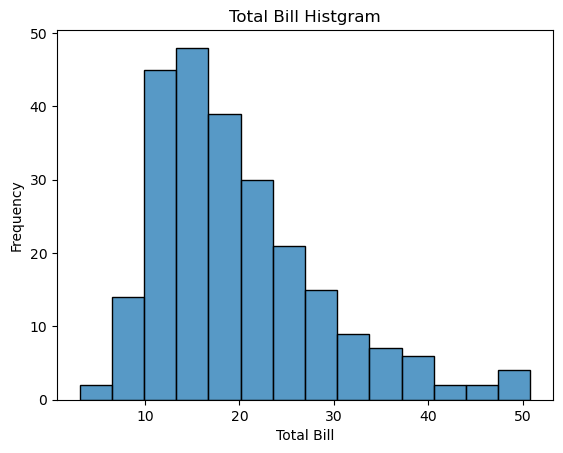

In [33]:
ax = plt.subplots()
ax = sns.histplot(tips['total_bill'], kde=False)
ax.set_title('Total Bill Histgram')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Frequency')

AttributeError: Rectangle.set() got an unexpected keyword argument 'hist'

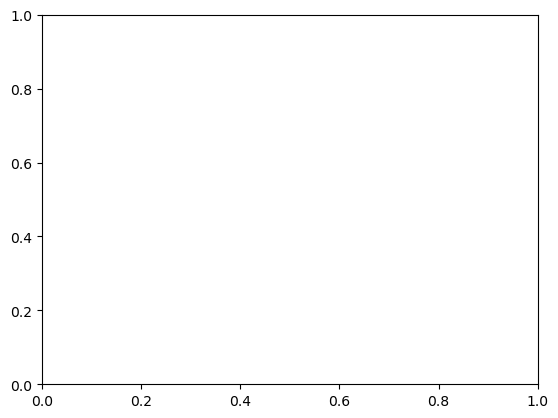

In [34]:
ax = plt.subplots()
ax = sns.histplot(tips['total_bill'], hist=False)
ax.set_title('Total Bill Density')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Unit Probability')
# error

Text(0.5, 0, 'Total Bill')

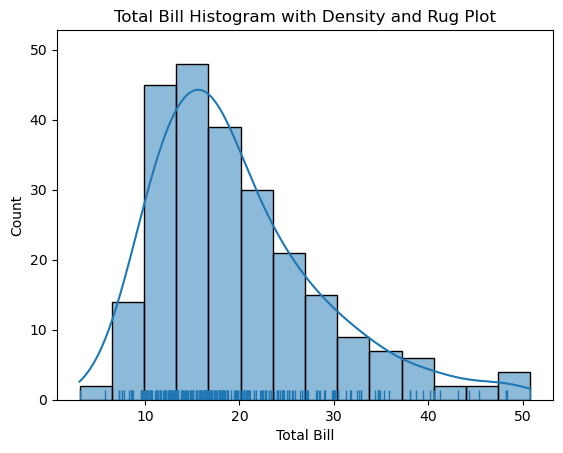

In [47]:
ax = plt.subplots()
ax = sns.histplot(tips['total_bill'], kde=True)
ax = sns.rugplot(tips['total_bill'])
ax.set_title('Total Bill Histogram with Density and Rug Plot')
ax.set_xlabel('Total Bill')

Text(0, 0.5, 'Frequency')

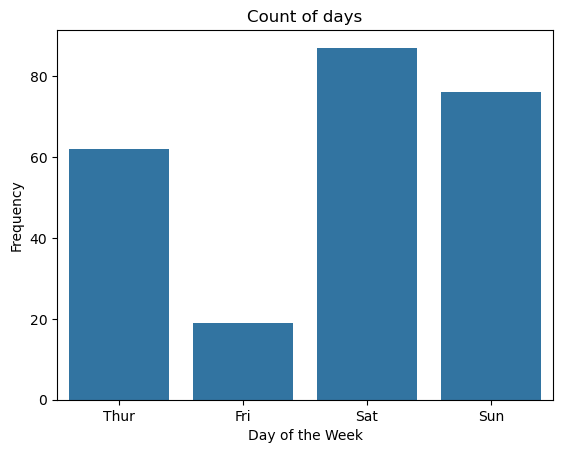

In [49]:
ax = plt.subplots()
ax = sns.countplot(x='day', data=tips)
ax.set_title('Count of days')
ax.set_xlabel('Day of the Week')
ax.set_ylabel('Frequency')
# x를 지정해야 함

In [ ]:
# 다양한 종류의 이변량 그래프 그리기

Text(0, 0.5, 'Tip')

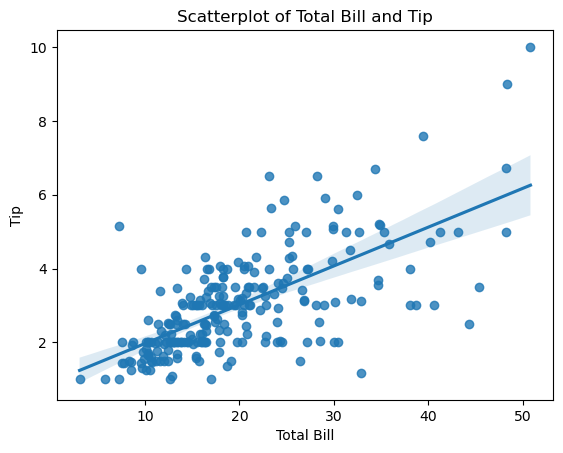

In [50]:
ax = plt.subplots()
ax = sns.regplot(x='total_bill', y='tip', data=tips)
ax.set_title('Scatterplot of Total Bill and Tip')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Tip')

Text(0, 0.5, 'Tip')

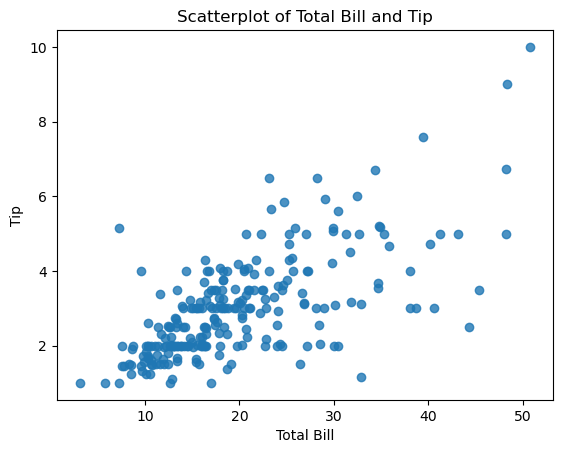

In [51]:
ax = plt.subplots()
ax = sns.regplot(x='total_bill', y='tip', data=tips, fit_reg=False)
ax.set_title('Scatterplot of Total Bill and Tip')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Tip')

Text(0.5, 1.03, 'Joint Plot of Total Bill and Tip')

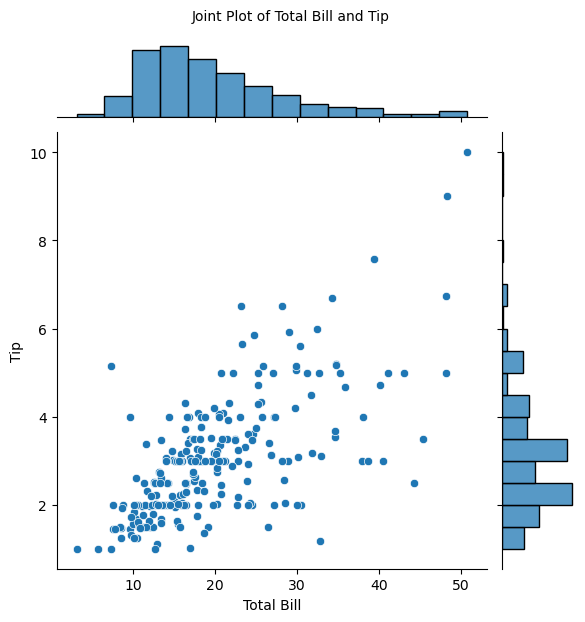

In [52]:
joint = sns.jointplot(x='total_bill', y='tip', data=tips)
joint.set_axis_labels(xlabel='Total Bill', ylabel='Tip')
joint.fig.suptitle('Joint Plot of Total Bill and Tip', 
                   fontsize=10, y=1.03)

Text(0.5, 1.03, 'Hexbin Joint Plot of Total Bill and Tip')

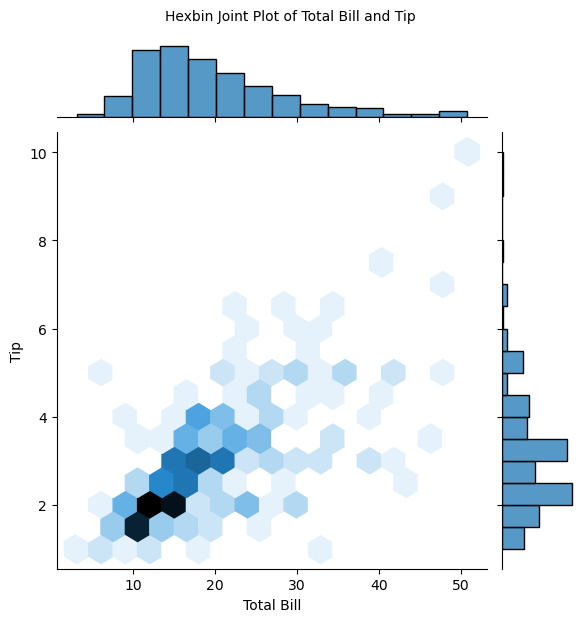

In [53]:
hexbin = sns.jointplot(x="total_bill", y="tip", data=tips, kind="hex")
hexbin.set_axis_labels(xlabel='Total Bill', ylabel='Tip')
hexbin.fig.suptitle('Hexbin Joint Plot of Total Bill and Tip',
                    fontsize=10, y=1.03)

Text(0, 0.5, 'Tip')

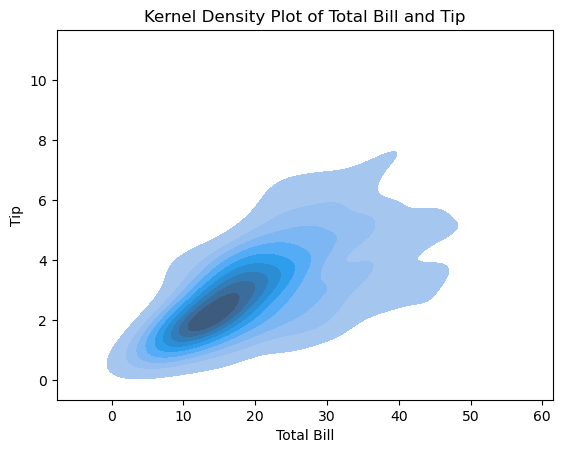

In [57]:
# 이차원 밀집도 그리기
ax = plt.subplots()
ax = sns.kdeplot(x=tips['total_bill'],
                 y=tips['tip'],
                 fill=True)
ax.set_title('Kernel Density Plot of Total Bill and Tip')
ax.set_xlabel('Total Bill')
ax.set_ylabel('Tip')
# shade -> fill 변경, data변수 사용 X -> x, y 변경

Text(0, 0.5, 'Average total bill')

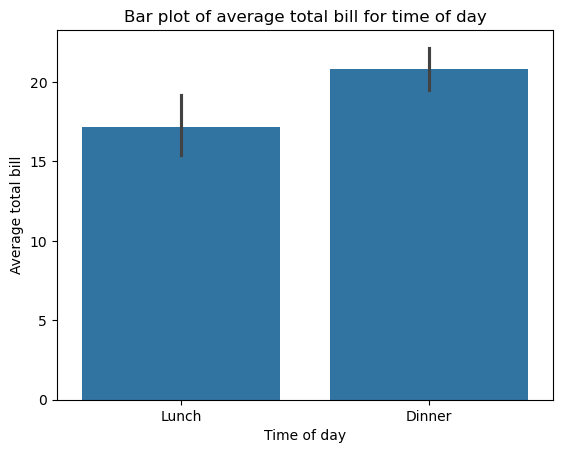

In [58]:
# 바 그래프 그리기
ax = plt.subplots()
ax = sns.barplot(x='time', y='total_bill', data=tips)
ax.set_title('Bar plot of average total bill for time of day')
ax.set_xlabel('Time of day')
ax.set_ylabel('Average total bill')

Text(0, 0.5, 'Total Bill')

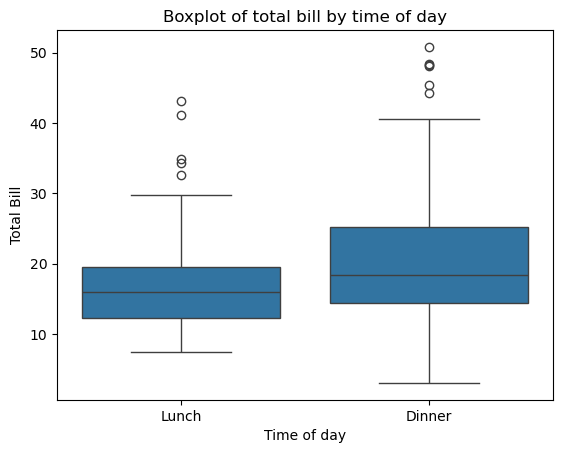

In [59]:
# 박스 그래프 그리기
ax = plt.subplots()
ax = sns.boxplot(x='time', y='total_bill', data=tips)
ax.set_title('Boxplot of total bill by time of day')
ax.set_xlabel('Time of day')
ax.set_ylabel('Total Bill')

Text(0, 0.5, 'Total Bill')

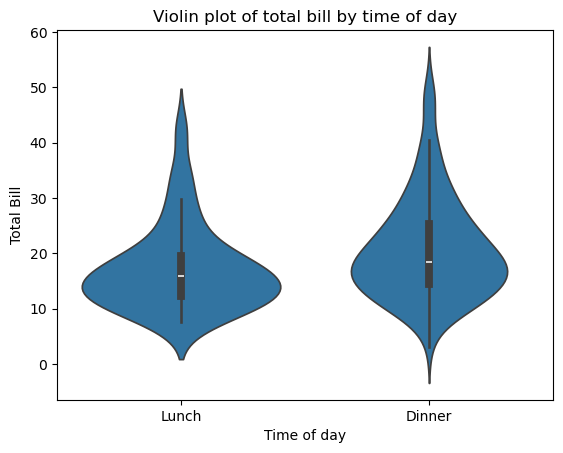

In [60]:
ax = plt.subplots()
ax = sns.violinplot(x='time', y='total_bill', data=tips)
ax.set_title('Violin plot of total bill by time of day')
ax.set_xlabel('Time of day')
ax.set_ylabel('Total Bill')

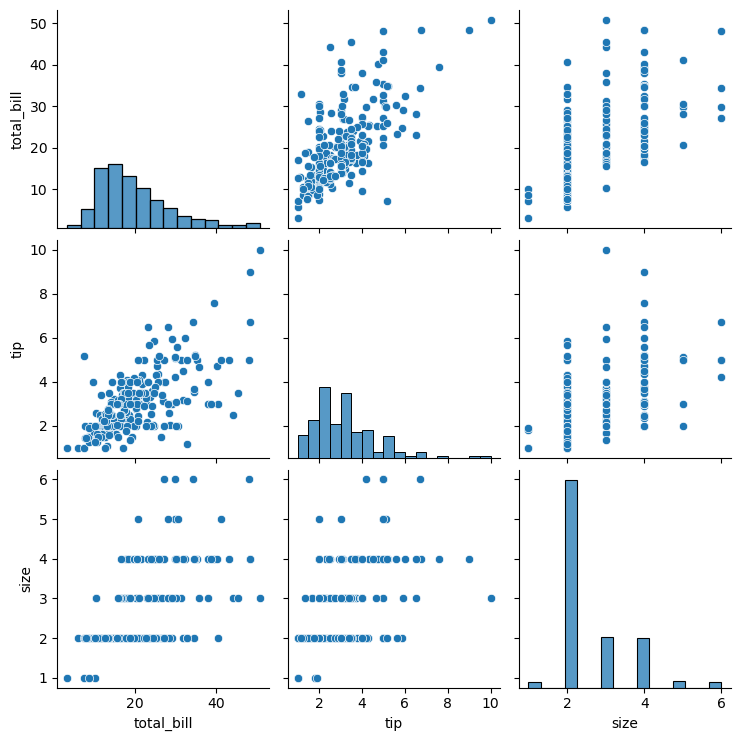

In [61]:
# 관계 그래프 그리기
fig = sns.pairplot(tips)

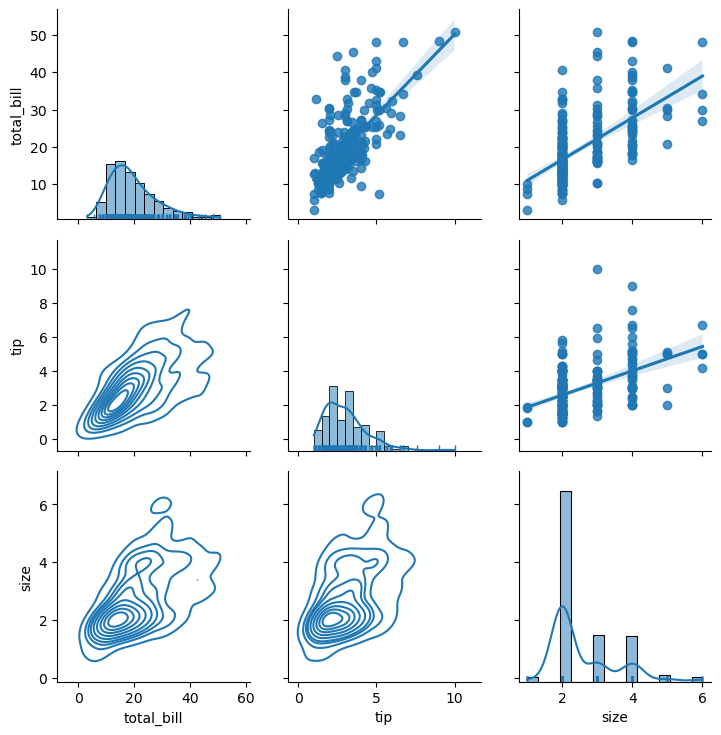

In [69]:
pair_grid = sns.PairGrid(tips)
pair_grid = pair_grid.map_upper(sns.regplot)
pair_grid = pair_grid.map_lower(sns.kdeplot)
pair_grid = pair_grid.map_diag(sns.histplot, kde=True)
pair_grid = pair_grid.map_diag(sns.rugplot)
plt.show()
# rug함수 따로 분리

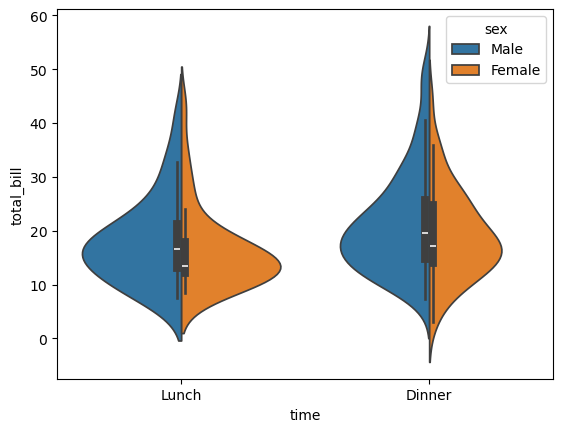

In [70]:
# 다변량 그래프 그리기
ax = plt.subplots()
ax = sns.violinplot(x='time', y='total_bill', hue='sex', 
                    data=tips, split=True)

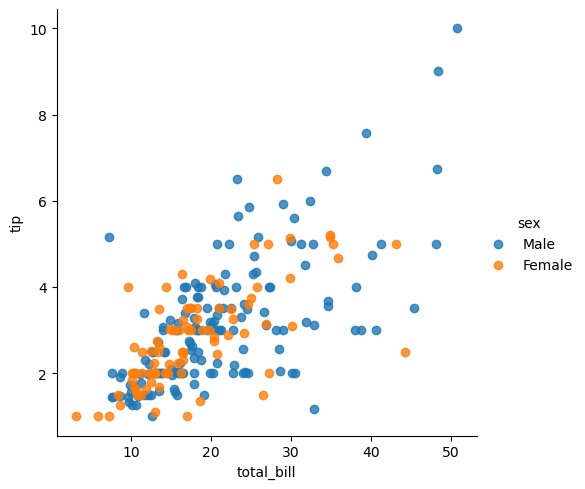

In [71]:
# 산점도, 관계 그래프 그리기
scatter = sns.lmplot(x='total_bill', y='tip', data=tips,
                     hue='sex', fit_reg=False)

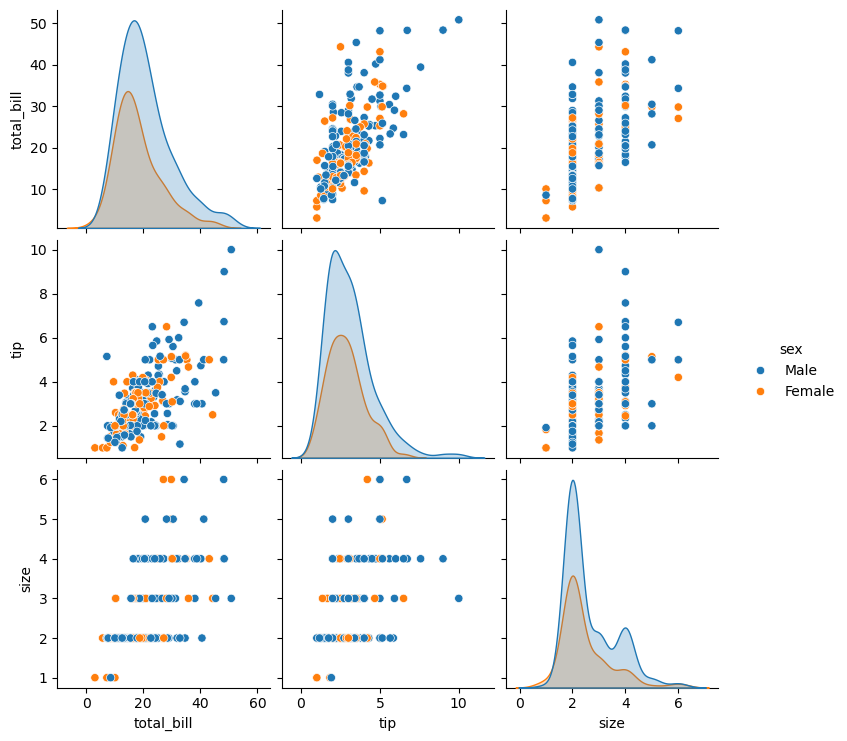

In [72]:
fig = sns.pairplot(tips, hue='sex')

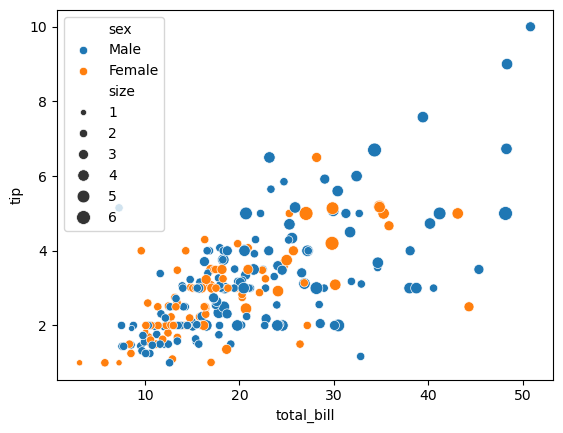

In [81]:
scatter = sns.scatterplot(
    x='total_bill',
    y='tip',
    data=tips,
    hue='sex',
    size='size',
    sizes=(20,100)
)
# lmplot은 데이터 크기때문에 오류 -> scatterplot 사용

<Axes: xlabel='total_bill', ylabel='tip'>

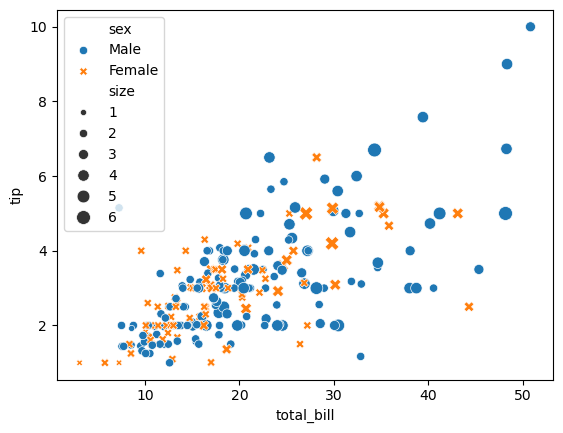

In [87]:
sns.scatterplot(
    x='total_bill',
    y='tip',
    data=tips,
    hue='sex',
    size='size',
    style='sex',
    markers=['o','X'],
    sizes=(20,100)
)

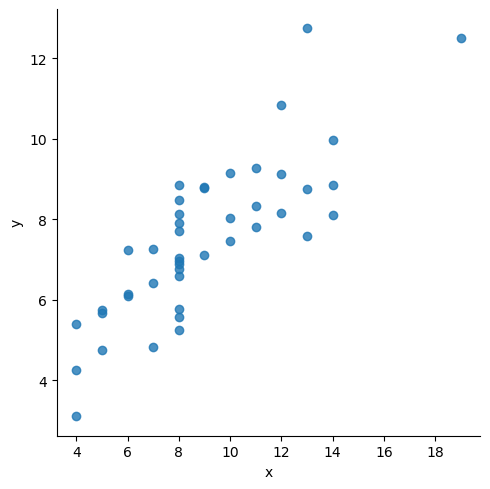

In [88]:
anscombe_plot = sns.lmplot(x='x', y='y', data=anscombe,
                           fit_reg=False)

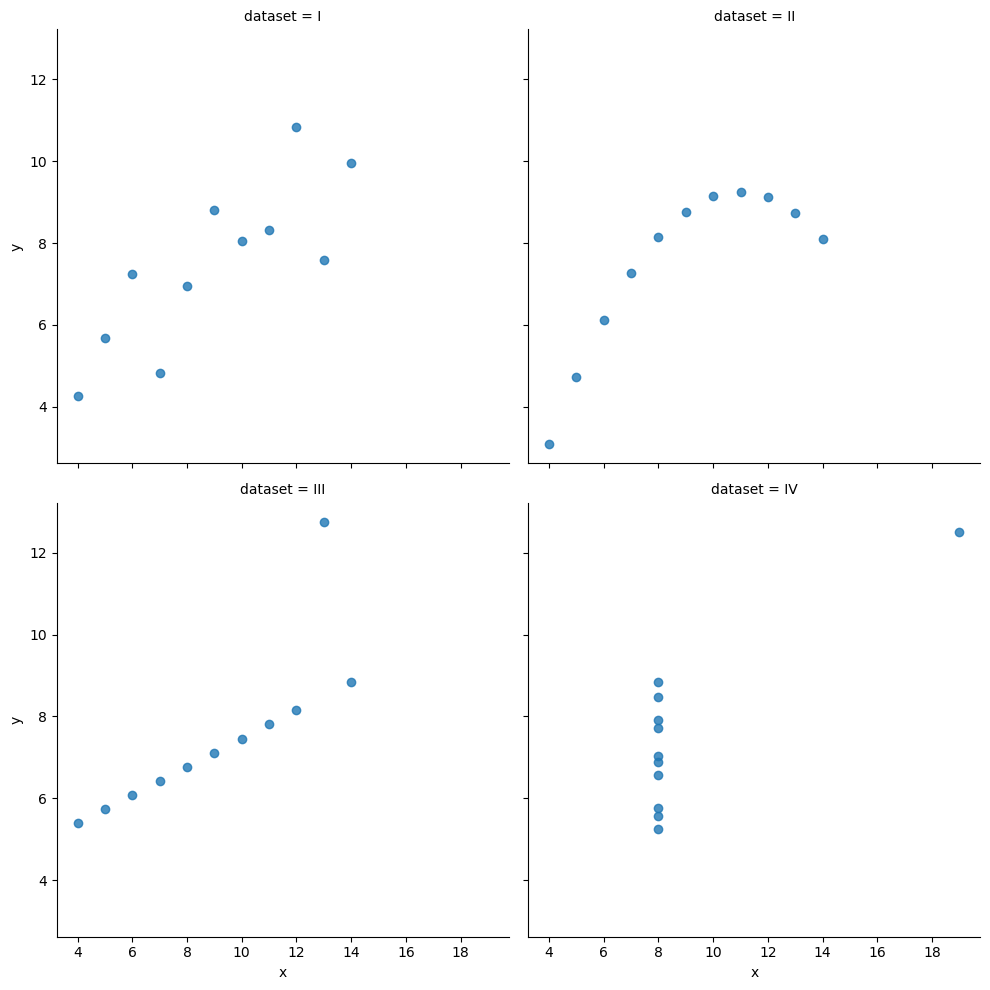

In [89]:
anscombe_plot = sns.lmplot(x='x', y='y', data=anscombe,
                           fit_reg=False, col='dataset', col_wrap=2)

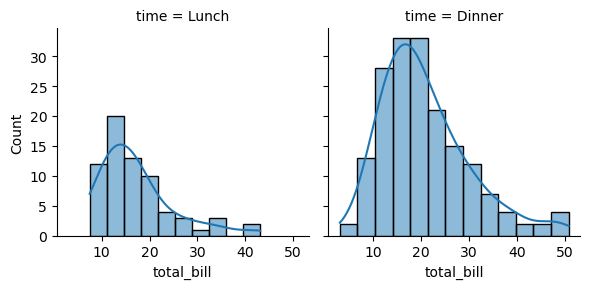

In [94]:
facet = sns.FacetGrid(tips, col='time')
facet.map(sns.histplot, 'total_bill', kde=True)
facet.map(sns.rugplot)

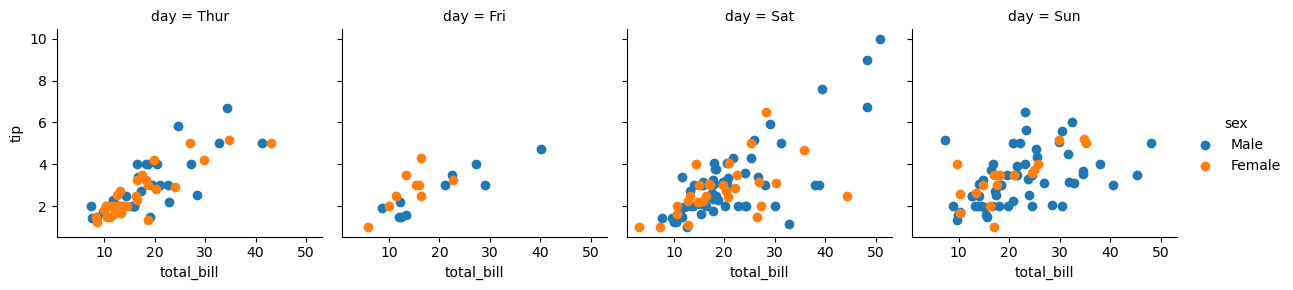

In [95]:
facet = sns.FacetGrid(tips, col='day', hue='sex')
facet = facet.map(plt.scatter, 'total_bill', 'tip')
facet = facet.add_legend()

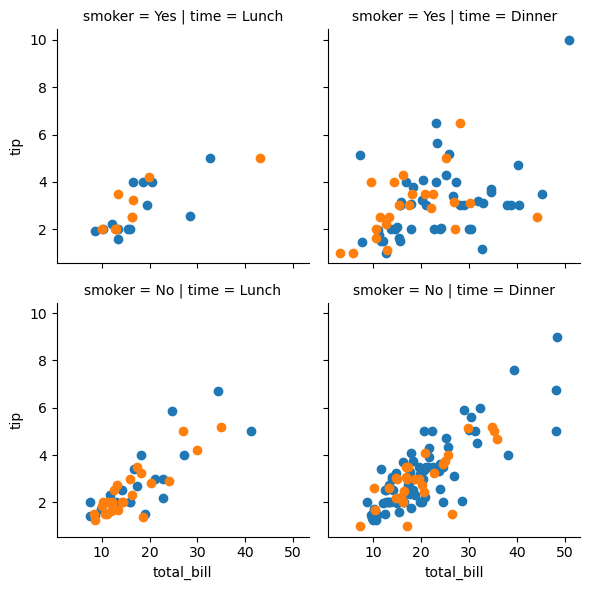

In [96]:
facet = sns.FacetGrid(tips, col='time', row='smoker', hue='sex')
facet.map(plt.scatter, 'total_bill', 'tip')

In [ ]:
# 04-4 데이터프레임과 시리즈로 그래프 그리기

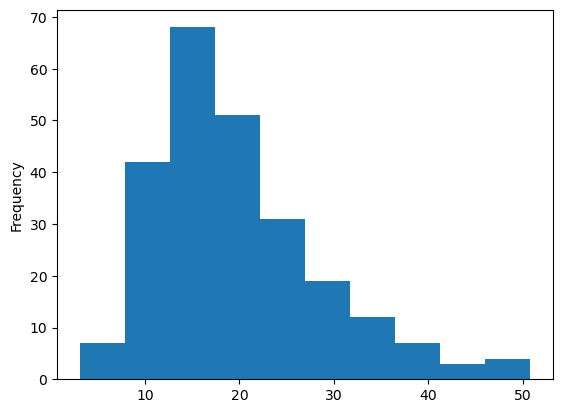

In [97]:
ax = plt.subplots()
ax = tips['total_bill'].plot.hist()

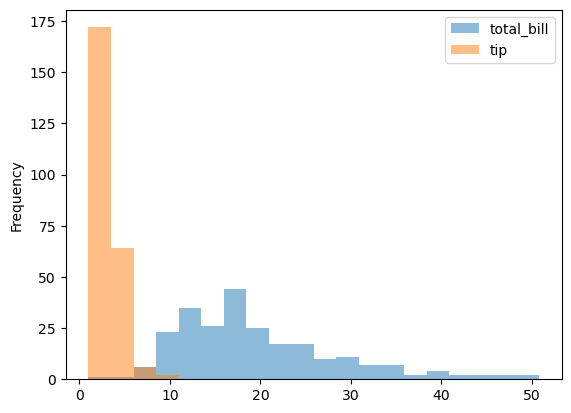

In [98]:
fig, ax = plt.subplots()
ax = tips[['total_bill', 'tip']].plot.hist(alpha=0.5, bins=20,
                                           ax=ax)

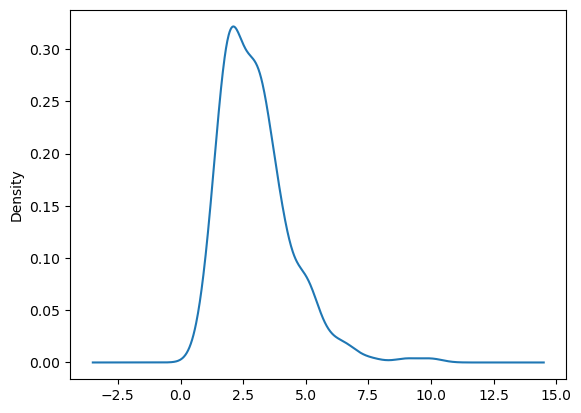

In [99]:
ax = plt.subplots()
ax = tips['tip'].plot.kde()

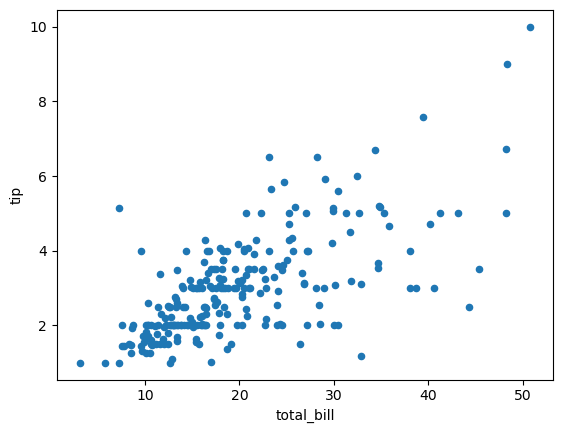

In [100]:
fig, ax = plt.subplots()
ax = tips.plot.scatter(x='total_bill', y='tip', ax=ax)

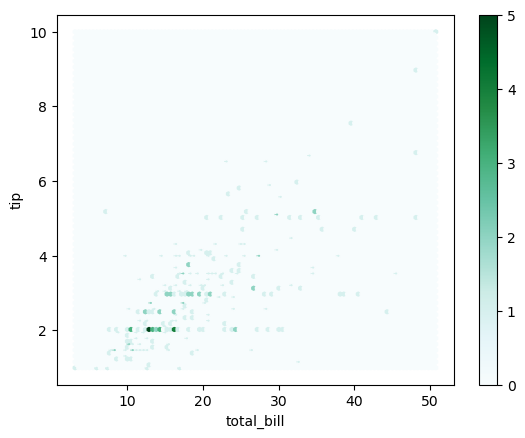

In [101]:
fig, ax = plt.subplots()
ax = tips.plot.hexbin(x='total_bill', y='tip', ax=ax)

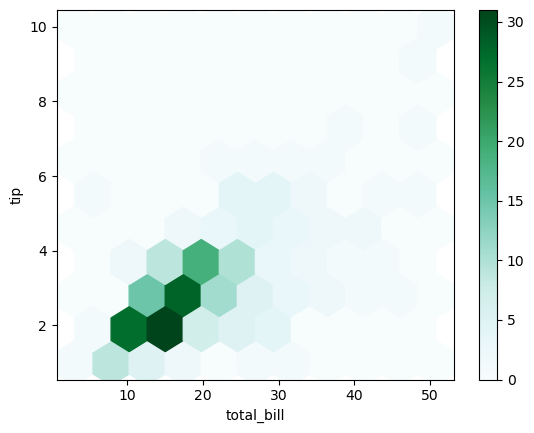

In [102]:
fig, ax = plt.subplots()
ax = tips.plot.hexbin(x='total_bill', y='tip', gridsize=10,
                      ax=ax)

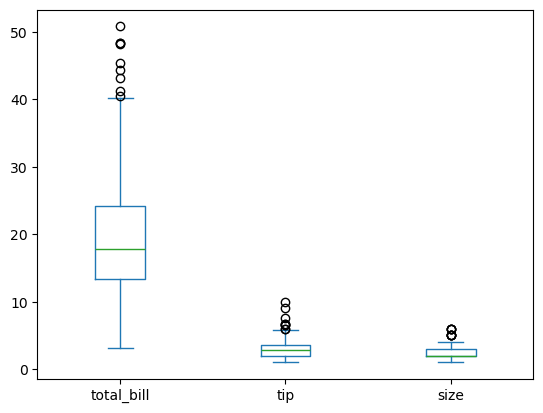

In [103]:
fig, ax = plt.subplots()
ax = tips.plot.box(ax=ax)

In [ ]:
# 04-5 seaborn 라이브러리로 그래프 스타일 설정하기

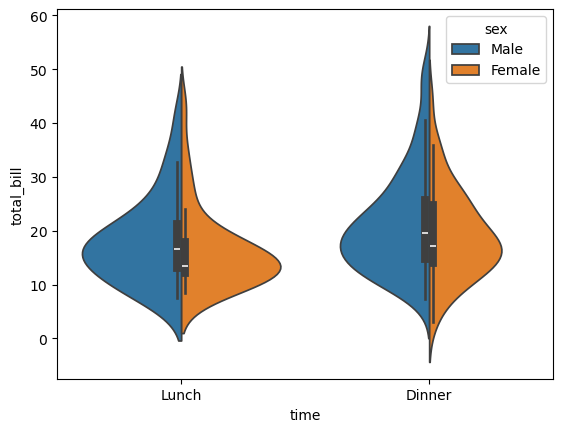

In [104]:
fig, ax = plt.subplots()
ax = sns.violinplot(x='time', y='total_bill', hue='sex', 
                    data=tips, split=True)

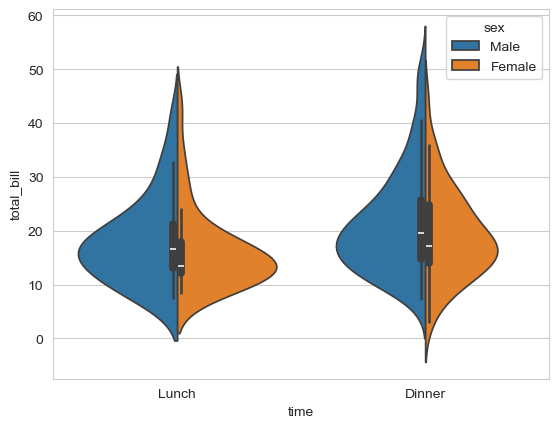

In [105]:
sns.set_style('whitegrid')
fig, ax = plt.subplots()
ax = sns.violinplot(x='time', y='total_bill', hue='sex',
                    data=tips, split=True)

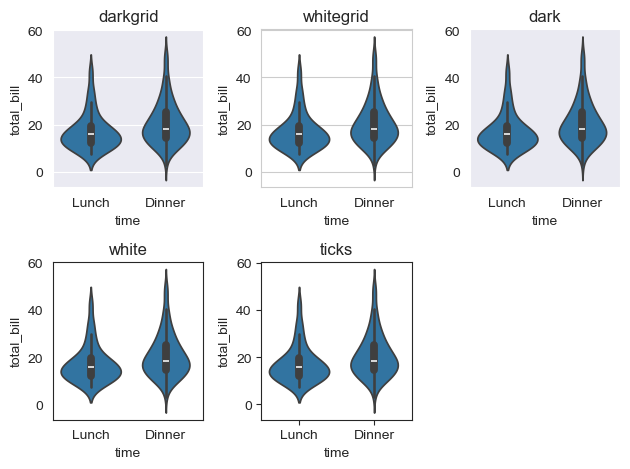

In [106]:
fig = plt.figure()

seaborn_styles = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']

for idx, style in enumerate(seaborn_styles):
    plot_position = idx + 1
    with sns.axes_style(style):
        ax = fig.add_subplot(2, 3, plot_position)
        violin = sns.violinplot(x='time', y='total_bill',
        data=tips, ax=ax)
        violin.set_title(style)

fig.tight_layout()